In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.api import VAR


In [63]:
def grangers_causation_matrix(data : np.array, variables : list, conditional_variables : dict):

    df_causality = pd.DataFrame(np.zeros((len(variables), len(variables))), columns=variables, index=variables)
    df_p_values = pd.DataFrame(np.zeros((len(variables), len(variables))), columns=variables, index=variables)

    abundances_sum = np.sum(data, axis=0) # sum of all species in every time step

    for i,r in enumerate(df_causality.index):
        for j,c in enumerate(df_causality.columns): # data[[x,y]] opposite to the other granger causality test file, which returns y causing x
                                                                    # the rest of the species, not X or Y
            
            data_tuple = pd.DataFrame({'X': data[i], 'Y': data[j]})

            data_tuple = data_tuple.assign(**conditional_variables)  # add conditional variables to the DataFrame

            try:
                model = VAR(data_tuple)
                results = model.fit(maxlags=1)
                causality = results.test_causality(caused='Y', causing=['X'], kind='f')

                df_p_values.loc[r, c] = causality.pvalue
                df_causality.loc[r, c] = results.coefs[0][1][0] # get the coefficient of X in the regression of Y
            except Exception as e:
                # likely if the time series are all or almost all zeros
                df_p_values.loc[r, c] = 1
                df_causality.loc[r, c] = 0
            # print(c)
            # print(r)
            # print(min_p_value)
            # print(df.loc[r, c])

    return df_causality.values, df_p_values.values

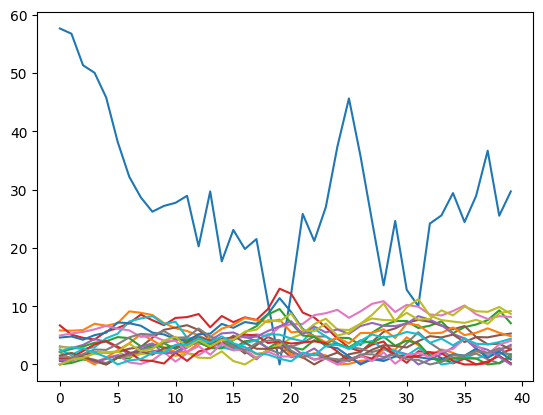

In [96]:
# matrix NxT of random data
N = 20
T = 40
np.random.seed(1)
data = np.random.rand(N, T) - 0.5
# make it cumulative, so that it looks more like abundances
data = np.cumsum(data, axis=1)
# for every spacies, substract the lowest value, so that all values are positive
data = data - np.min(data, axis=1, keepdims=True)
data[0] = data[0] * 10

# make percentages, all species sum up to 100 at each time step
data = data / np.sum(data, axis=0) * 100

variables = ['species_' + str(i) for i in range(N)]

plt.plot(data.T);

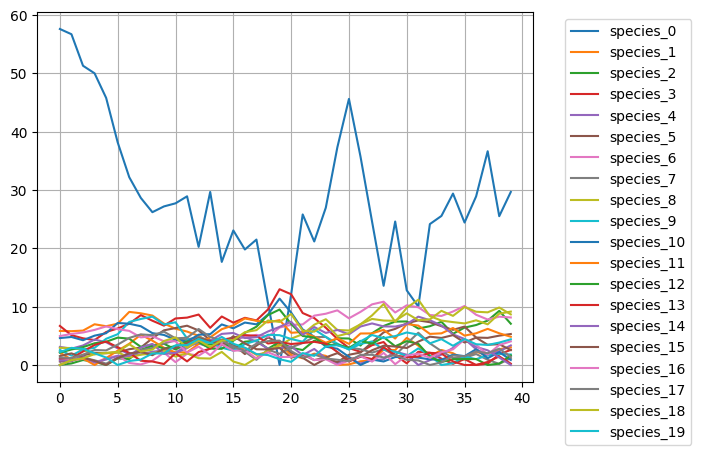

In [111]:
plt.plot(data.T)
plt.legend(variables, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()

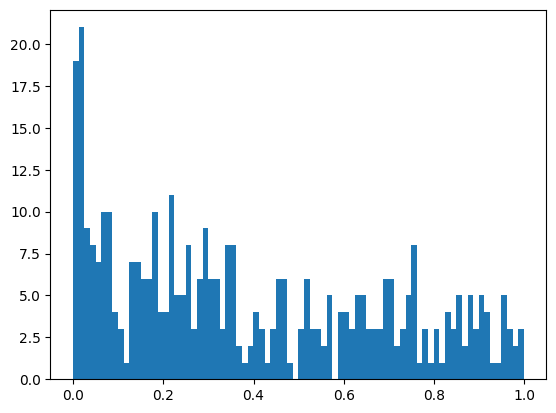

In [105]:
# calculate causality matrix

causality_matrix, p_values = grangers_causation_matrix(data, variables, conditional_variables={})
# flatten p_values matrix but remove diagonal
plt.hist(p_values[~np.eye(p_values.shape[0],dtype=bool)].flatten(), bins=80);

In [ ]:
# bootstrap to get more robust p-values
def stationary_bootstrap(x):
    # repeat the data once for periodicity, and not choose data out of the range
    x_period = np.concatenate((x, x))

    x_final = np.array([])
    while True:
        L = np.random.randint(low=1, high=len(x))
        x_0 = np.random.randint(low=0, high=len(x))
        
        if len(x_final) + L < len(x):
            # choose L data points from x_period starting from x_0
            x_final = np.concatenate((x_final, x_period[x_0:x_0+L]))
        else:
            # fill the remaining data points
            x_final = np.concatenate((x_final, x_period[x_0:x_0+len(x)-len(x_final)]))
            return x_final

n_bootstrap = 100
p_values_bootstrap = np.zeros((N, N))

for b in range(n_bootstrap):
    print(b)
    data_bootstrap = np.zeros_like(data)
    for i in range(data.shape[0]):
        data_bootstrap[i, :] = stationary_bootstrap(data[i, :])

    causality_b, p_values_b = grangers_causation_matrix(data_bootstrap, variables, conditional_variables={})
    # if the absolute value of the causality is larger than the original one, then the p-value adds one
    p_values_bootstrap[:, :] += (np.abs(causality_b) >= np.abs(causality_matrix)).astype(int)
# divide by the number of bootstraps to get the p-value
p_values_bootstrap = p_values_bootstrap / n_bootstrap
print(p_values_bootstrap)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
[[1.   0.12 0.98 0.93 0.65 0.54 0.98 0.43 0.97 0.34 0.63 0.73 0.16 0.83
  0.83 0.38 0.05 0.08 0.88 0.73]
 [0.77 1.   0.36 0.5  0.53 0.67 0.27 0.44 0.31 0.22 0.71 0.4  0.92 0.98
  0.48 0.76 0.49 0.1  0.32 0.59]
 [0.91 0.62 1.   0.36 0.82 0.39 0.75 0.78 0.25 0.06 0.31 0.57 0.45 0.29
  0.21 0.39 0.98 0.23 0.12 0.11]
 [0.77 0.56 0.38 1.   0.96 0.24 0.76 0.22 0.8  0.8  0.35 0.57 0.55 0.21
  0.46 0.52 0.47 0.75 0.45 0.36]
 [0.77 0.89 0.26 0.45 1.   0.18 0.93 0.63 0.95 0.14 0.07 0.51 0.16 0.08
  0.69 0.44 0.52 0.45 0.92 0.2 ]
 [0.48 0.72 0.78 0.5  0.42 1.   0.82 0.79 0.68 0.18 0.41 0.6  0.45 0.89
  0.72 0.01 0.92 0.77 0.85 0.76]
 [0.88 0.23 0.12 0.24 0.24 0.77 1.   0.6  0.05 0.18 0.24 0.67 0.32 0.41
  0.29 0

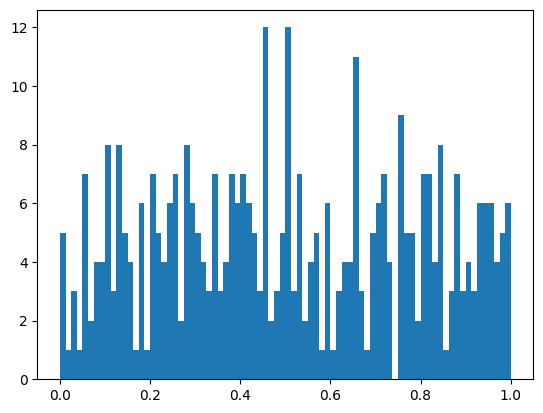

In [114]:
plt.hist(p_values_bootstrap[~np.eye(p_values_bootstrap.shape[0],dtype=bool)].flatten(), bins=80);

In [113]:
# get the largest bootstrapped p-values, get the pairs of species that have the lowest p-values
rows = []
species_index_T = {i: 'species_' + str(i) for i in range(N)}

for i in range(p_values_bootstrap.shape[0]):
    for j in range(p_values_bootstrap.shape[1]):
        if not np.isnan(p_values_bootstrap[i, j]):
            row = {'species_1': species_index_T[i], 'species_2': species_index_T[j], 'p_value': p_values_bootstrap[i, j]}
            rows.append(row)

p_values_df = pd.DataFrame(rows)
p_values_df = p_values_df.sort_values(by='p_value', ascending=True)
p_values_df

,species_1,species_2,p_value
156,species_7,species_16,0.00
219,species_10,species_19,0.00
203,species_10,species_3,0.00
389,species_19,species_9,0.00
115,species_5,species_15,0.01
...,...,...,...
315,species_15,species_15,1.00
335,species_16,species_15,1.00
336,species_16,species_16,1.00
210,species_10,species_10,1.00
